In [6]:
import glob, os
import matplotlib.pyplot as plt
from PIL import Image
import random

files = glob.glob("/kaggle/input/**/*.jpg", recursive=True)
print("Nombre d'images :", len(files))
print(files[:3])

def label_of(f):
    parent = os.path.basename(os.path.dirname(f)).lower()
    name = os.path.basename(f).lower()
    return "cat" if ("cat" in parent or name.startswith("cat")) else "dog"

labels = [label_of(f) for f in files]
print("Chats :", labels.count("cat"), "| Chiens :", labels.count("dog"))

Nombre d'images : 10028
['/kaggle/input/datasets/tongpython/cat-and-dog/test_set/test_set/dogs/dog.4329.jpg', '/kaggle/input/datasets/tongpython/cat-and-dog/test_set/test_set/dogs/dog.4223.jpg', '/kaggle/input/datasets/tongpython/cat-and-dog/test_set/test_set/dogs/dog.4253.jpg']
Chats : 5011 | Chiens : 5017


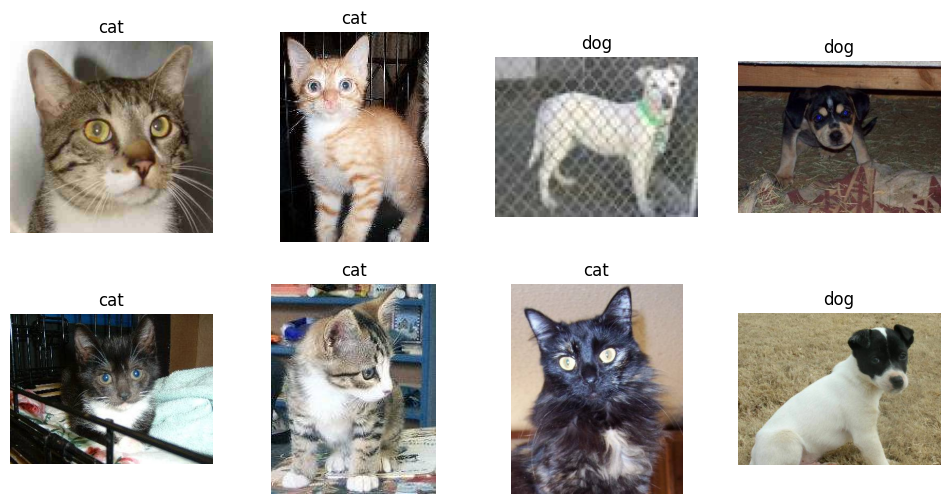

In [7]:
random.seed(0)
idx = random.sample(range(len(files)), 8)

plt.figure(figsize=(12, 6))
for i, j in enumerate(idx):
    plt.subplot(2, 4, i + 1)
    plt.imshow(Image.open(files[j]))
    plt.title(labels[j])
    plt.axis("off")
plt.show()

In [8]:
import numpy as np
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# Échantillon de 3000 images
random.seed(42)
sel = random.sample(range(len(files)), 3000)
sel_files = [files[i] for i in sel]
y = np.array([1 if labels[i] == "dog" else 0 for i in sel])   # 0 = chat, 1 = chien

def hog_features(f):
    img = Image.open(f).convert("L").resize((128, 128))
    return hog(np.array(img), orientations=9, pixels_per_cell=(16, 16), cells_per_block=(2, 2))

X_hog = np.array([hog_features(f) for f in sel_files])
print("Taille des features :", X_hog.shape)

Taille des features : (3000, 1764)


Précision HOG + SVM : 0.737
              precision    recall  f1-score   support

        chat       0.73      0.76      0.75       305
       chien       0.74      0.71      0.73       295

    accuracy                           0.74       600
   macro avg       0.74      0.74      0.74       600
weighted avg       0.74      0.74      0.74       600



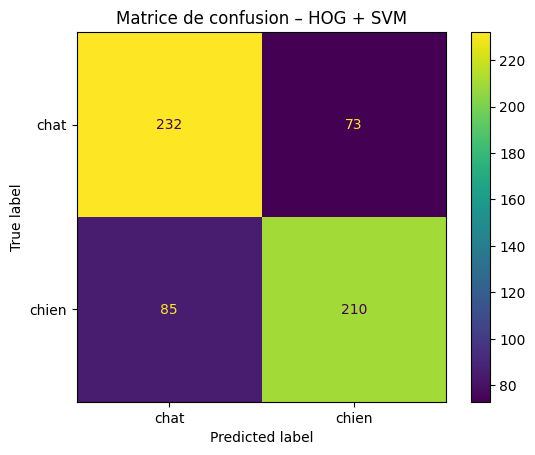

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_hog, y, test_size=0.2, random_state=42, stratify=y)

svm_hog = SVC(kernel="rbf", C=10, gamma="scale")
svm_hog.fit(X_train, y_train)

y_pred = svm_hog.predict(X_test)
print("Précision HOG + SVM :", round(accuracy_score(y_test, y_pred), 3))
print(classification_report(y_test, y_pred, target_names=["chat", "chien"]))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["chat", "chien"])
plt.title("Matrice de confusion – HOG + SVM")
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input

base = MobileNetV2(weights="imagenet", include_top=False, pooling="avg", input_shape=(160, 160, 3))

def load(f):
    return np.array(Image.open(f).convert("RGB").resize((160, 160)), dtype=np.float32)

feats = []
for i in range(0, len(sel_files), 64):
    batch = np.stack([load(f) for f in sel_files[i:i + 64]])
    feats.append(base.predict(preprocess_input(batch), verbose=0))
X_cnn = np.vstack(feats)
print("Taille des features CNN :", X_cnn.shape)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
   print(X_cnn.shape)

(3000, 1280)


Précision CNN + SVM : 0.98
              precision    recall  f1-score   support

        chat       0.98      0.98      0.98       305
       chien       0.98      0.98      0.98       295

    accuracy                           0.98       600
   macro avg       0.98      0.98      0.98       600
weighted avg       0.98      0.98      0.98       600



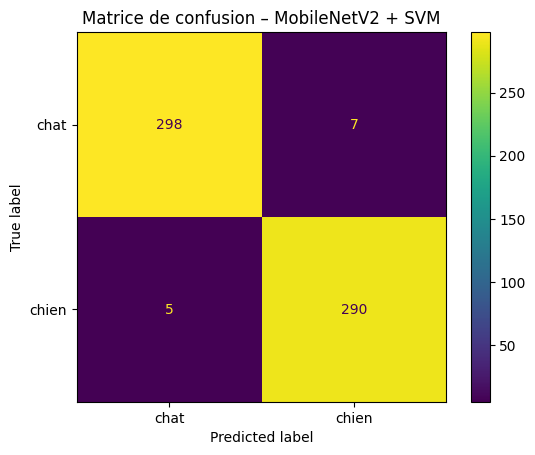

In [12]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cnn, y, test_size=0.2, random_state=42, stratify=y)

svm_cnn = SVC(kernel="rbf", C=10, gamma="scale")
svm_cnn.fit(Xc_train, yc_train)

yc_pred = svm_cnn.predict(Xc_test)
print("Précision CNN + SVM :", round(accuracy_score(yc_test, yc_pred), 3))
print(classification_report(yc_test, yc_pred, target_names=["chat", "chien"]))

ConfusionMatrixDisplay.from_predictions(yc_test, yc_pred, display_labels=["chat", "chien"])
plt.title("Matrice de confusion – MobileNetV2 + SVM")
plt.show()

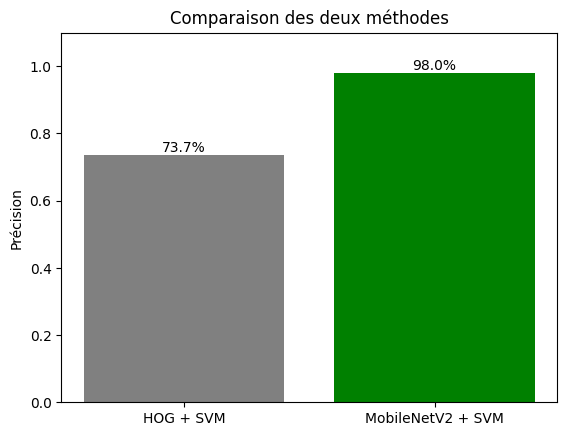

In [13]:
acc_hog = accuracy_score(y_test, y_pred)
acc_cnn = accuracy_score(yc_test, yc_pred)

plt.bar(["HOG + SVM", "MobileNetV2 + SVM"], [acc_hog, acc_cnn], color=["gray", "green"])
for i, v in enumerate([acc_hog, acc_cnn]):
    plt.text(i, v + 0.01, f"{v:.1%}", ha="center")
plt.ylim(0, 1.1)
plt.ylabel("Précision")
plt.title("Comparaison des deux méthodes")
plt.show()

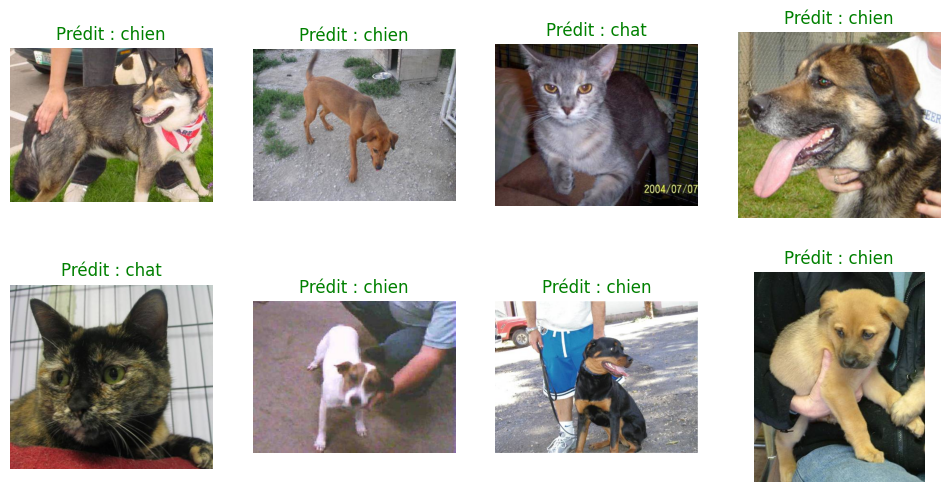

In [14]:
_, test_files = train_test_split(sel_files, test_size=0.2, random_state=42, stratify=y)
noms = ["chat", "chien"]

plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(Image.open(test_files[i]))
    ok = yc_pred[i] == yc_test[i]
    plt.title(f"Prédit : {noms[yc_pred[i]]}", color="green" if ok else "red")
    plt.axis("off")
plt.show()

## Conclusion
- Objectif : classer des images de chats et de chiens avec un **SVM**
- Données : 3000 images (Kaggle Cat and Dog), 80 % entraînement / 20 % test
- Méthode 1 – **HOG + SVM** : précision **73,7 %** (le HOG ne capte que les contours)
- Méthode 2 – **MobileNetV2 (pré-entraîné) + SVM** : précision **98,0 %**
- Le SVM est identique : c'est la qualité des caractéristiques qui fait la différence.
- Le transfer learning permet d'obtenir d'excellents résultats avec peu de données et peu de calcul.